# SARIMAX & Gradient Boosting Modelling for NSW Electricity Demand Forecasting

## 1. Objective

The aim of this notebook is to develop and evaluate forecasting models for NSW electricity demand using historical demand, temperature, and engineered time-based features. A SARIMAX model is used as a statistical baseline, and a Gradient Boosting model is introduced as a machine learning approach.

Models are evaluated over multiple forecasting horizons using mean squared error (MSE) and root mean squared error (RMSE). Comparison with the provided forecast is limited to the 48-step horizon, where it is used as a benchmark, while longer horizons are used to compare model performance within the project.

## 2. Import libraries

This section imports the Python libraries required for data handling, visualisation, time series modelling, and model evaluation.

- `pandas` and `numpy` are used for data manipulation
- `matplotlib` is used for visualisation
- `statsmodels` provides the SARIMAX model
- `sklearn` is used to calculate evaluation metrics such as MSE and RMSE

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, root_mean_squared_error
from sklearn.ensemble import GradientBoostingRegressor

## 3. Load data

In this section, the preprocessed training, validation, and test datasets are loaded. These datasets were generated during the preprocessing stage to ensure consistency across all models in the project.

Using pre-split datasets allows for a fair comparison between models and avoids data leakage. The data is recorded at 30-minute intervals, which informs the temporal structure used in the forecasting models.

The test dataset also includes provided forecast values (P01–P48), representing the 1 to 48 step-ahead forecasts for each timestamp. These are used as a benchmark for comparison at the 48-step horizon.

The model is trained on the training set and evaluated on the test set.

In [2]:
# Load datasets from project root (notebook in src/)
from pathlib import Path
root = Path.cwd().resolve().parents[0]  # project root when running from src/

train_path = root / 'data' / 'NSW' / 'train.csv'
validation_path = root / 'data' / 'NSW' / 'validation.csv'
test_path = root / 'data' / 'NSW' / 'test.csv'


train = pd.read_csv(train_path, parse_dates=['DATETIME'], index_col='DATETIME')
validation = pd.read_csv(validation_path, parse_dates=['DATETIME'], index_col='DATETIME')
test = pd.read_csv(test_path, parse_dates=['DATETIME'], index_col='DATETIME')

# Quick check
print("Train shape:", train.shape)
print("Validation shape:", validation.shape)
print("Test shape:", test.shape)
train.head()

Train shape: (112651, 7)
Validation shape: (37550, 7)
Test shape: (37552, 55)


,TOTALDEMAND,demand_1_day_ago,demand_1_week_ago,demand_1_year_ago,TEMPERATURE,RMSE_48,TSE_48
DATETIME,,,,,,,
2010-07-02 12:00:00,11409.84,10035.63,9766.12,8038.00,11.0,637.616980,1.951466e+07
2010-07-02 12:30:00,11276.77,9686.17,9521.15,7809.31,11.5,706.576978,2.396405e+07
2010-07-02 13:00:00,11208.75,9513.42,9318.45,7483.69,11.6,784.498292,2.954100e+07
2010-07-02 13:30:00,11184.47,9255.59,9108.57,7117.23,11.8,862.789475,3.573147e+07
2010-07-02 14:00:00,11141.20,9019.79,8863.47,6812.03,12.0,927.314578,4.127579e+07


## 4. Data inspection

Before fitting the model, the structure and properties of the dataset are examined. 
This includes checking the data types, confirming the presence of key variables, and ensuring that the datetime index is correctly formatted.

Understanding the dataset at this stage helps identify any potential issues and ensures that the forecasting models are applied appropriately.

The test dataset additionally contains multi-step provided forecasts (P01–P48), which represent 1 to 48 step-ahead predictions for each timestamp and will be used as a benchmark for model comparison.

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 112651 entries, 2010-07-02 12:00:00 to 2016-12-04 09:00:00
Data columns (total 7 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   TOTALDEMAND        112651 non-null  float64
 1   demand_1_day_ago   112651 non-null  float64
 2   demand_1_week_ago  112651 non-null  float64
 3   demand_1_year_ago  112651 non-null  float64
 4   TEMPERATURE        112651 non-null  float64
 5   RMSE_48            112651 non-null  float64
 6   TSE_48             112651 non-null  float64
dtypes: float64(7)
memory usage: 6.9 MB


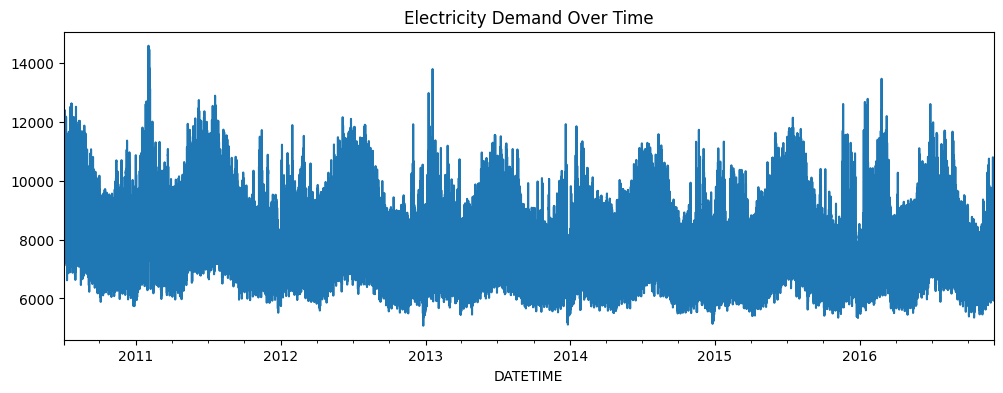

In [3]:
# Check data types and structure
train.info()

# Summary statistics
train.describe()

# Check for missing values
train.isna().sum()

# Quick visual of target variable
train['TOTALDEMAND'].plot(figsize=(12,4), title='Electricity Demand Over Time')
plt.show()

The time series plot shows clear periodic patterns, including strong daily cycles and longer-term seasonal variation. This indicates that electricity demand is influenced by recurring temporal patterns, making it suitable for time series forecasting approaches.

Additionally, the data is recorded at 30-minute intervals, which informs the choice of a seasonal period of 48 for models that incorporate seasonality.

In [4]:
# Set 30-minute frequency for time series modelling
train = train.sort_index()
validation = validation.sort_index()
test = test.sort_index()

train.index.freq = '30min'
validation.index.freq = '30min'
test.index.freq = '30min'
train.index.to_series().diff().value_counts().head()

DATETIME
0 days 00:30:00    112650
Name: count, dtype: int64

## 5. Define target and exogenous variables

The target variable for the models is total electricity demand (TOTALDEMAND).

Temperature is included as an exogenous variable, as it captures the impact of weather conditions on electricity usage.

The provided forecast demand is not used as an input feature in the models. Instead, it is treated as an external benchmark for comparison to ensure a fair evaluation of model performance.

Lagged demand variables are not included in the SARIMAX model, as it captures temporal dependencies internally through its autoregressive structure. However, lagged features are used in the Gradient Boosting model to provide historical context, as tree-based models do not inherently account for time dependencies.

Including temperature allows the models to incorporate external influences while maintaining a valid and fair forecasting setup.

In [5]:
# Target variable
y_train = train['TOTALDEMAND']
y_val = validation['TOTALDEMAND']
y_test = test['TOTALDEMAND']

# Exogenous variables
exog_vars = ['TEMPERATURE']

X_train = train[exog_vars]
X_val = validation[exog_vars]
X_test = test[exog_vars]
print(X_train.head())

# Clean and align training data
combined_train = pd.concat([y_train, X_train], axis=1).dropna()

y_train_clean = combined_train['TOTALDEMAND']
X_train_clean = combined_train[['TEMPERATURE']]

# Forecast horizons
horizons = [48, 336, 720]
window_start = 436


                     TEMPERATURE
DATETIME                        
2010-07-02 12:00:00         11.0
2010-07-02 12:30:00         11.5
2010-07-02 13:00:00         11.6
2010-07-02 13:30:00         11.8
2010-07-02 14:00:00         12.0


## 6. Helper functions

To keep the notebook concise and consistent, helper functions are defined for forecasting, metric calculation, and visualisation. 
This avoids unnecessary repetition and ensures that each model is evaluated using the same process.

In [6]:
def run_forecast(model_results, X_test, y_test, window_start, horizon):
    """
    Generate forecast and calculate error metrics for a given horizon.
    """
    y_actual = y_test.iloc[window_start:window_start + horizon]
    X_exog = X_test.iloc[window_start:window_start + horizon]

    forecast = model_results.get_forecast(
        steps=horizon,
        exog=X_exog
    )

    y_pred = forecast.predicted_mean

    rmse = np.sqrt(mean_squared_error(y_actual, y_pred))
    mse = mean_squared_error(y_actual, y_pred)

    return y_actual, y_pred


def plot_forecast(y_actual, y_pred, provided_forecast, horizon, title):
    plt.figure(figsize=(10, 5))

    plt.plot(range(horizon), y_actual.values, label='Actual Demand')
    plt.plot(range(horizon), y_pred.values, label=title)

    if provided_forecast is not None:
        plt.plot(range(horizon), provided_forecast.values, label='Provided Forecast')

    plt.title(f'{horizon}-step Forecast Comparison')
    plt.xlabel('Step Ahead')
    plt.ylabel('Electricity Demand')
    plt.legend()
    plt.grid()
    plt.show()

def extract_provided_forecast_diagonal(test_df, window_start, horizon):
    """
    Extract provided forecast using diagonal alignment:
    row 0 -> P01, row 1 -> P02, ..., row h-1 -> P{h:02d}
    """
    window_df = test_df.iloc[window_start:window_start + horizon].copy()

    provided_seq = np.array([
        window_df.iloc[i][f'P{i+1:02d}'] for i in range(horizon)
    ], dtype=np.float32)

    return pd.Series(provided_seq, index=window_df.index)

## 7. SARIMAX Model

### 7.1 Model Specification

The first model developed in this notebook is a baseline SARIMAX model. This model is intended to provide an interpretable statistical baseline for short-term forecasting of NSW electricity demand.

The target variable is TOTALDEMAND, while TEMPERATURE is included as the exogenous variable. Temperature is included because electricity demand is influenced by weather conditions, making it a relevant external driver of demand.

The provided forecast is not used as an input to the SARIMAX model. Instead, it is treated as an external benchmark for comparison at the 48-step horizon to ensure a fair evaluation of model performance.

Given that the data is recorded at 30-minute intervals, a seasonal period of 48 is used to represent daily seasonality. A relatively simple model structure is used to keep the baseline interpretable and computationally efficient.

The baseline model specification is:
- non-seasonal order: (1,1,0)
- seasonal order: (0,1,0,48)

In [7]:
# Fit baseline SARIMAX model
model_SARIMAX = SARIMAX(
    y_train_clean,
    exog=X_train_clean,
    order=(1, 1, 0),
    seasonal_order=(0, 1, 0, 48),
    enforce_stationarity=False,
    enforce_invertibility=False,
)

results_SARIMAX = model_SARIMAX.fit(disp=False, maxiter=20, method='lbfgs')

### 7.2 Forecasting Results

The SARIMAX model is evaluated using a fixed forecast window in the test set to ensure consistency with the other models in the project. Forecasts are generated for three horizons to evaluate model performance across short- and longer-term predictions:

• 48 steps (1 day)  
• 336 steps (7 days)  
• 720 steps (15 days)  

Comparison with the provided forecast is only conducted at the 48-step horizon, as longer horizons are not available.

Performance is assessed using RMSE and MSE, and visual comparison is used to assess how well the model captures the overall demand pattern and peak behaviour.

In [8]:
SARIMAX_results = {}

for h in horizons:
    y_actual, y_pred = run_forecast(
        results_SARIMAX, X_test, y_test, window_start, h
    )

    rmse = np.sqrt(mean_squared_error(y_actual, y_pred))
    mse = mean_squared_error(y_actual, y_pred)

    SARIMAX_results[h] = (y_actual, y_pred, rmse, mse)

    print(f"[SARIMAX] Horizon {h}")
    print(f"RMSE: {rmse:.2f}")
    print(f"MSE: {mse:.2f}")
    print("-" * 30)

[SARIMAX] Horizon 48
RMSE: 3259.33
MSE: 10623227.98
------------------------------
[SARIMAX] Horizon 336
RMSE: 2857.06
MSE: 8162787.97
------------------------------
[SARIMAX] Horizon 720
RMSE: 3076.95
MSE: 9467640.97
------------------------------


In [9]:
horizon = 48
n_windows = len(test) - horizon + 1

actual_all_list = []
provided_all_list = []

for start in range(n_windows):
    # actual demand for this 48-step window
    actual_seq = test.iloc[start:start + horizon]['TOTALDEMAND'].values

    # provided forecast using Kam-style diagonal extraction
    window_df = test.iloc[start:start + horizon].copy()
    provided_seq = np.array([
        window_df.iloc[i][f'P{i+1:02d}'] for i in range(horizon)
    ], dtype=np.float32)

    actual_all_list.append(actual_seq)
    provided_all_list.append(provided_seq)

# flatten all windows
actual_all = np.concatenate(actual_all_list)
provided_all = np.concatenate(provided_all_list)

# all-window metrics for provided forecast only
rmse_provided_all = np.sqrt(mean_squared_error(actual_all, provided_all))
mse_provided_all = mean_squared_error(actual_all, provided_all)

print("[Provided Forecast] All windows")
print(f"RMSE: {rmse_provided_all:.6f}")
print(f"MSE: {mse_provided_all:.6f}")

[Provided Forecast] All windows
RMSE: 271.898098
MSE: 73928.575557


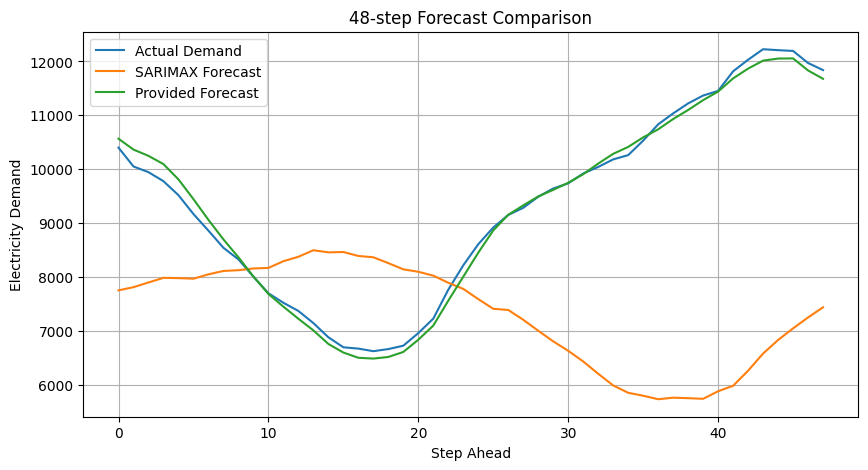

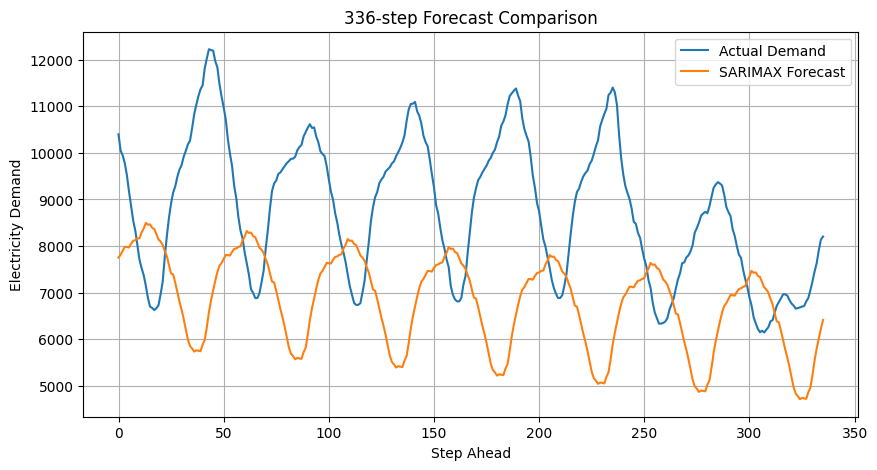

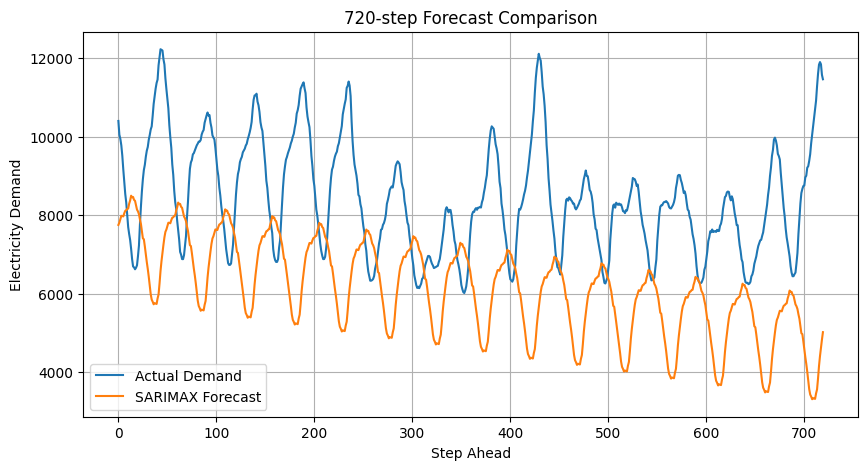

In [10]:
for h in horizons:
    y_actual, y_pred, rmse, mse = SARIMAX_results[h]

    if h == 48:
        provided = extract_provided_forecast_diagonal(test, window_start, h)
    else:
        provided = None

    plot_forecast(
        y_actual,
        y_pred,
        provided,
        h,
        'SARIMAX Forecast'
    )

The SARIMAX model performs reasonably as a baseline for short-term forecasting, but shows clear limitations even at the 48-step horizon. While it captures some general movement in demand, the forecast is significantly biased downward and fails to match the overall level and variability of the actual series. In particular, peak demand is consistently underestimated and the magnitude of fluctuations is not well represented.  

As the forecast horizon increases, these issues become more pronounced. At the 336-step and 720-step horizons, the model exhibits a strong downward bias and struggles to accurately reproduce both the amplitude and timing of cyclical demand patterns. Although some periodic behaviour is visible, the forecasts remain systematically lower than the observed values, indicating that errors accumulate over time.  

For benchmarking, the provided forecast is evaluated separately using all available 48-step windows with diagonal extraction. This enables a consistent comparison at the short-term horizon, where both approaches are directly comparable. The provided forecast significantly outperforms the SARIMAX model, achieving substantially lower error and closely tracking both the level and peaks of demand.  

Overall, while the SARIMAX model provides an interpretable statistical baseline, its inability to capture the correct level, peak demand, and longer-term dynamics highlights the need for more flexible modelling approaches.

## 8. Machine Learning Benchmark (Gradient Boosting)

### 8.1 Model Specification

To provide a benchmark against the statistical SARIMAX model, a gradient boosting regression model was implemented. Unlike SARIMAX, gradient boosting treats the forecasting task as a supervised machine learning regression problem, learning patterns from a set of engineered input features rather than modelling the time series structure directly.

The model uses a combination of lagged demand variables, weather information, and calendar-based features. In particular, lagged demand values are included to capture short-term and daily temporal dependencies, while temperature, temperature², and calendar features are used to represent external and cyclical influences on electricity demand.

The provided forecast is not used as an input feature in the Gradient Boosting model. Instead, it is treated as an external benchmark for comparison at the 48-step horizon to ensure a fair evaluation of model performance.

The feature set used in the model is:

- lag 1
- lag 2
- lag 3
- lag 48
- lag 96
- rolling mean (6 steps)
- rolling mean (48 steps)
- temperature
- temperature²
- hour of day
- day of week
- weekend indicator

This model is included as a machine learning benchmark to assess whether a more flexible nonlinear approach can better capture the complex patterns in electricity demand forecasting.

In [11]:
# -----------------------------------
# Prepare full dataset for feature engineering
# -----------------------------------
full_data = pd.concat([train, validation, test]).sort_index().copy()

# Nonlinear + calendar features
full_data['TEMP_SQUARED'] = full_data['TEMPERATURE'] ** 2
full_data['HOUR'] = full_data.index.hour
full_data['DAYOFWEEK'] = full_data.index.dayofweek
full_data['IS_WEEKEND'] = (full_data['DAYOFWEEK'] >= 5).astype(int)

# Lag features
full_data['lag_1'] = full_data['TOTALDEMAND'].shift(1)
full_data['lag_2'] = full_data['TOTALDEMAND'].shift(2)
full_data['lag_3'] = full_data['TOTALDEMAND'].shift(3)
full_data['lag_48'] = full_data['TOTALDEMAND'].shift(48)
full_data['lag_96'] = full_data['TOTALDEMAND'].shift(96)

# Rolling Averages
full_data['rolling_mean_6'] = full_data['TOTALDEMAND'].shift(1).rolling(6).mean()
full_data['rolling_mean_48'] = full_data['TOTALDEMAND'].shift(1).rolling(48).mean()

# Feature list
gb_features = [
    'lag_1',
    'lag_2',
    'lag_3',
    'lag_48',
    'lag_96',
    'rolling_mean_6',
    'rolling_mean_48',
    'TEMPERATURE',
    'TEMP_SQUARED',
    'HOUR',
    'DAYOFWEEK',
    'IS_WEEKEND'
]

# Training data only (for fair comparison with SARIMAX)
train_gb = full_data.loc[train.index].dropna(subset=gb_features + ['TOTALDEMAND']).copy()

X_train_gb = train_gb[gb_features]
y_train_gb = train_gb['TOTALDEMAND']

# Fit gradient boosting model
gb_model = GradientBoostingRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=5,
    random_state=42
)

gb_model.fit(X_train_gb, y_train_gb)

GradientBoostingRegressor(learning_rate=0.03, max_depth=5, n_estimators=500,
                          random_state=42)

In [12]:
def run_gb_recursive_forecast(model, full_data, test, window_start, horizon, feature_cols):
    """
    Recursive multi-step forecast for Gradient Boosting model.
    """

    freq = pd.Timedelta(minutes=30)
    forecast_index = test.index[window_start:window_start + horizon]

    # Use all known actual demand up to the forecast origin
    history_end = forecast_index[0] - freq
    history = list(full_data.loc[:history_end, 'TOTALDEMAND'].values)

    preds = []

    for ts in forecast_index:
        temp = test.loc[ts, 'TEMPERATURE']

        row = pd.DataFrame([{
            'lag_1': history[-1],
            'lag_2': history[-2],
            'lag_3': history[-3],
            'lag_48': history[-48],
            'lag_96': history[-96],
            'rolling_mean_6': np.mean(history[-6:]),
            'rolling_mean_48': np.mean(history[-48:]),
            'TEMPERATURE': temp,
            'TEMP_SQUARED': temp ** 2,
            'HOUR': ts.hour,
            'DAYOFWEEK': ts.dayofweek,
            'IS_WEEKEND': int(ts.dayofweek >= 5)
        }])

        yhat = model.predict(row[feature_cols])[0]
        preds.append(yhat)
        history.append(yhat)

    y_actual = test.iloc[window_start:window_start + horizon]['TOTALDEMAND']
    y_pred = pd.Series(preds, index=forecast_index)

    rmse = np.sqrt(mean_squared_error(y_actual, y_pred))
    mse = mean_squared_error(y_actual, y_pred)

    return y_actual, y_pred, rmse, mse

### 8.2 Forecasting Results

The gradient boosting model is evaluated using the same forecast window and horizons as the SARIMAX model to ensure a fair comparison.

Forecasts are generated for:

• 48 steps (1 day)  
• 336 steps (7 days)  
• 720 steps (15 days)  

Comparison with the provided forecast is only conducted at the 48-step horizon, where multi-step benchmark forecasts (P01–P48) are available.

A recursive forecasting approach is used so that predicted values are fed back into the lag features for future steps. Performance is assessed using RMSE and MSE, and visual comparison is used to evaluate how well the model captures demand patterns.

In [13]:
gb_results = {}

for h in horizons:
    y_actual, y_pred, rmse, mse = run_gb_recursive_forecast(
        gb_model, full_data, test, window_start, h, gb_features
    )

    gb_results[h] = (y_actual, y_pred, rmse, mse)

    print(f"[Gradient Boosting] Horizon {h}")
    print(f"RMSE: {rmse:.2f}")
    print(f"MSE: {mse:.2f}")



[Gradient Boosting] Horizon 48
RMSE: 264.30
MSE: 69856.98
[Gradient Boosting] Horizon 336
RMSE: 1076.13
MSE: 1158046.85
[Gradient Boosting] Horizon 720
RMSE: 1096.55
MSE: 1202416.45


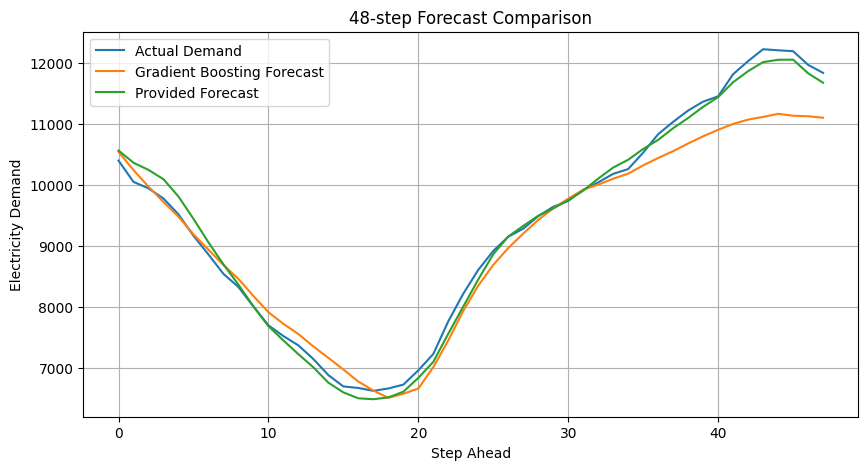

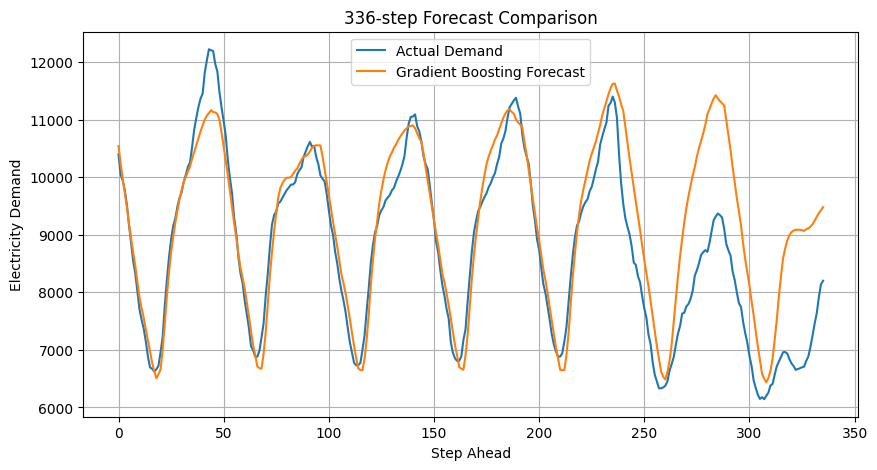

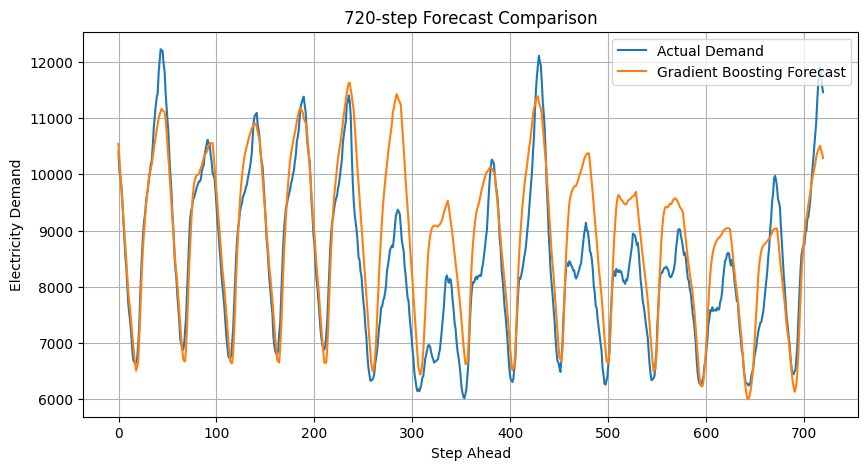

In [ ]:
for h in horizons:
    y_actual, y_pred, rmse, mse = gb_results[h]

    if h == 48:
        provided = extract_provided_forecast_diagonal(test, window_start, h)
    else:
        provided = None

    plot_forecast(
        y_actual,
        y_pred,
        provided,
        h,
        'Gradient Boosting Forecast'
    )

The gradient boosting model provides a strong machine learning benchmark against the SARIMAX model and highlights the benefits of a more flexible nonlinear approach for this forecasting task.  

At the 48-step horizon, the model achieved a substantially lower RMSE than the SARIMAX baseline and also outperformed the provided forecast on the selected evaluation window. This indicates that the gradient boosting model is highly effective at capturing short-term demand patterns, likely due to its use of lagged demand features, nonlinear temperature effects, and calendar-based predictors.  

At longer horizons of 336 and 720 steps, the model continues to perform well and maintains the overall level and cyclical structure of the series more effectively than the SARIMAX model. While some smoothing of peak demand is still evident, the gradient boosting model tracks the underlying demand patterns much more closely over extended periods.  

It is important to note that the provided forecast benchmark was evaluated across all available 48-step windows, whereas the gradient boosting model was assessed on a fixed forecast window. Despite this, the results demonstrate that machine learning approaches can achieve competitive and, in some cases, superior performance in short-term electricity demand forecasting.  

Overall, the gradient boosting model clearly outperforms the SARIMAX baseline and provides the strongest predictive performance among the models implemented in this notebook

## 9. Comparison of Models

This section compares the performance of the SARIMAX baseline and Gradient Boosting models across different forecasting horizons, with the provided forecast used as a benchmark where applicable.  

At the 48-step horizon, Gradient Boosting substantially outperformed the SARIMAX baseline in terms of RMSE and MSE. The model also more closely followed the observed demand pattern, particularly around turning points and peak demand. When compared to the provided forecast, the Gradient Boosting model achieved slightly lower error on the selected evaluation window, indicating strong short-term predictive performance. However, it is important to note that the provided forecast benchmark was computed across all available windows, whereas the model results are based on a fixed forecast window.  

At longer horizons (336 and 720 steps), Gradient Boosting continued to outperform the SARIMAX model by a large margin. While the SARIMAX model exhibited a strong downward drift and failed to capture peak demand, the Gradient Boosting model maintained more realistic demand levels and better reproduced cyclical patterns. Although some smoothing of peak values is still evident, the model tracks the overall structure of demand much more effectively over extended periods.  

The provided forecast is only available for the 48-step horizon, so comparisons at longer horizons are limited to the SARIMAX and Gradient Boosting models.  

Overall, Gradient Boosting provides the strongest performance across all horizons, demonstrating that machine learning approaches can significantly improve forecasting accuracy over traditional statistical models, particularly when nonlinear relationships and temporal dependencies are present.

### 9.1 Numerical Comparison

In [14]:
# --- 48-step comparison summary ---

h = 48

# Fixed-window model results
y_actual_s, y_pred_s, rmse_s, mse_s = SARIMAX_results[h]
y_actual_g, y_pred_g, rmse_g, mse_g = gb_results[h]

# All-window provided forecast benchmark (computed earlier)
print("=== 48-step Comparison Summary ===")
print(f"SARIMAX (fixed window) RMSE: {rmse_s:.2f} | MSE: {mse_s:.2f}")
print(f"Gradient Boosting (fixed window) RMSE: {rmse_g:.2f} | MSE: {mse_g:.2f}")
print(f"Provided Forecast (all windows) RMSE: {rmse_provided_all:.2f} | MSE: {mse_provided_all:.2f}")

=== 48-step Comparison Summary ===
SARIMAX (fixed window) RMSE: 3259.33 | MSE: 10623227.98
Gradient Boosting (fixed window) RMSE: 264.30 | MSE: 69856.98
Provided Forecast (all windows) RMSE: 271.90 | MSE: 73928.58


###  9.2 Plot — 48 Step

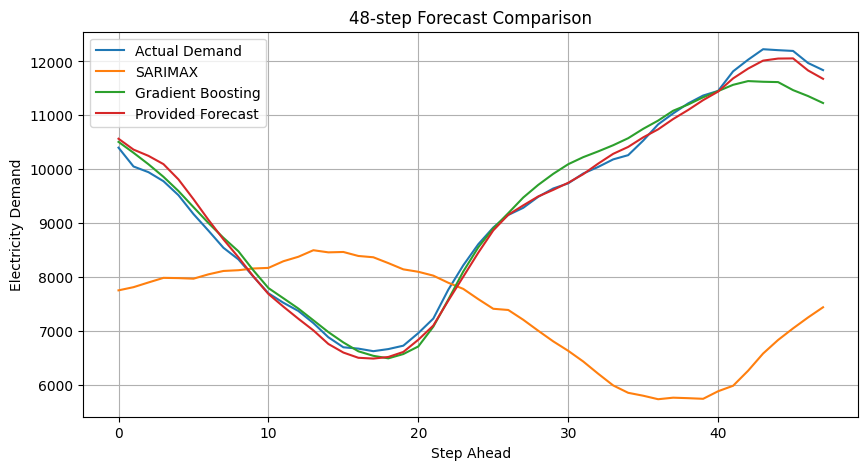

In [16]:
provided_plot = extract_provided_forecast_diagonal(test, window_start, h)
plt.figure(figsize=(10,5))

plt.plot(range(h), y_actual_s.values, label='Actual Demand')
plt.plot(range(h), y_pred_s.values, label='SARIMAX')
plt.plot(range(h), y_pred_g.values, label='Gradient Boosting')
plt.plot(range(h), provided_plot.values, label='Provided Forecast')

plt.title('48-step Forecast Comparison')
plt.xlabel('Step Ahead')
plt.ylabel('Electricity Demand')
plt.legend()
plt.grid()
plt.show()

### 9.3 Numerical Comparison (336 & 720)

In [17]:
for h in [336, 720]:

    y_actual_s, y_pred_s, rmse_s, mse_s = SARIMAX_results[h]
    y_actual_g, y_pred_g, rmse_g, mse_g = gb_results[h]

    print(f"\n=== {h}-step Comparison ===")
    print(f"SARIMAX RMSE: {rmse_s:.2f} | MSE: {mse_s:.2f}")
    print(f"Gradient Boosting RMSE: {rmse_g:.2f} | MSE: {mse_g:.2f}")


=== 336-step Comparison ===
SARIMAX RMSE: 2857.06 | MSE: 8162787.97
Gradient Boosting RMSE: 1076.13 | MSE: 1158046.85

=== 720-step Comparison ===
SARIMAX RMSE: 3076.95 | MSE: 9467640.97
Gradient Boosting RMSE: 1096.55 | MSE: 1202416.45


### 9.4 Plots — 336 & 720

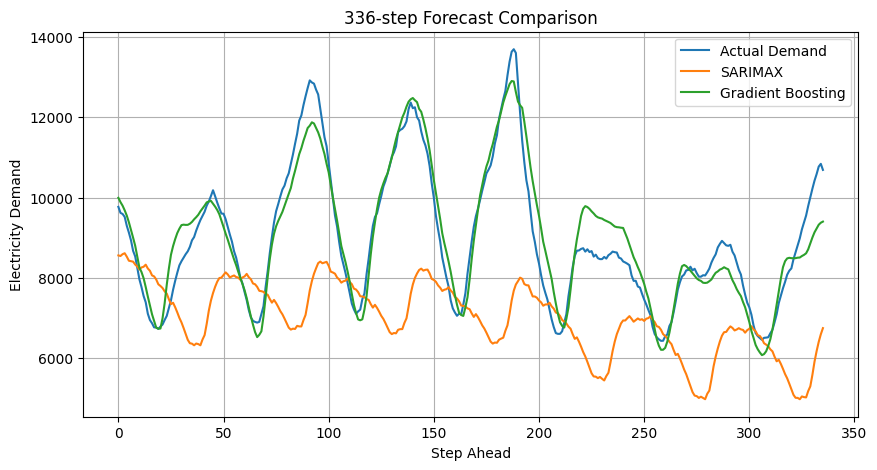

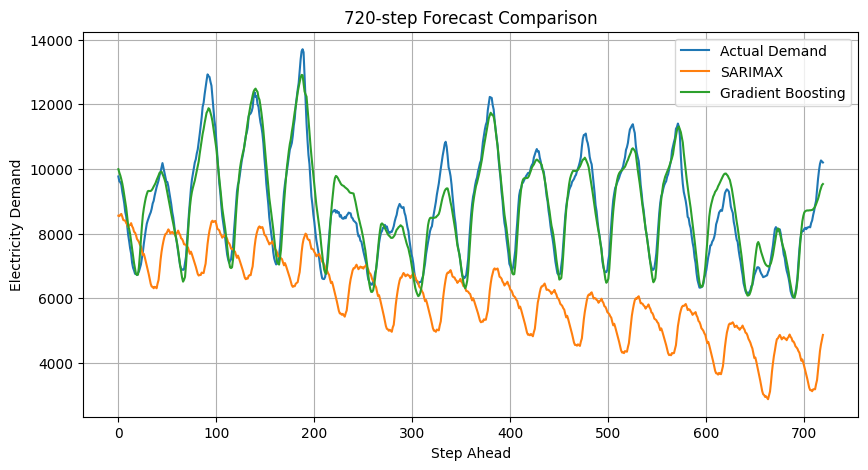

In [ ]:
for h in [336, 720]:

    y_actual_s, y_pred_s, _, _ = SARIMAX_results[h]
    y_actual_g, y_pred_g, _, _ = gb_results[h]

    plt.figure(figsize=(10,5))

    plt.plot(range(h), y_actual_s.values, label='Actual Demand')
    plt.plot(range(h), y_pred_s.values, label='SARIMAX')
    plt.plot(range(h), y_pred_g.values, label='Gradient Boosting')

    plt.title(f'{h}-step Forecast Comparison')
    plt.xlabel('Step Ahead')
    plt.ylabel('Electricity Demand')
    plt.legend()
    plt.grid()
    plt.show()

## 10. Conclusion

This notebook developed and evaluated forecasting models for NSW electricity demand across multiple time horizons using both statistical and machine learning approaches.  

The SARIMAX baseline model provided a simple and interpretable starting point, capturing some short-term patterns but struggling to accurately represent peak demand and longer-term behaviour. Model refinements, including the addition of a moving average term and nonlinear temperature features, led to only marginal improvements, with performance deteriorating as the forecast horizon increased.  

In contrast, the Gradient Boosting model demonstrated substantially stronger performance across all horizons. By incorporating lagged demand, nonlinear transformations, and calendar-based features, it was able to better capture both short-term fluctuations and longer-term cyclical patterns. This resulted in significantly lower forecast errors and more realistic demand predictions compared to the SARIMAX model.  

At the 48-step horizon, Gradient Boosting produced highly accurate forecasts and achieved slightly lower error than the provided forecast on the selected evaluation window. While the provided forecast benchmark was evaluated across all windows, the results suggest that a well-engineered machine learning approach can achieve competitive performance relative to existing forecasting benchmarks in short-term prediction tasks.  

Overall, the results highlight the limitations of traditional statistical models in capturing complex, nonlinear demand dynamics, and demonstrate the effectiveness of machine learning methods as flexible and accurate alternatives for electricity demand forecasting.